In [ ]:
# 1) Revenue / Booking Value Analysis
# What is the total booking value?
# What is the average booking value?
# What is the booking value by year?
# What is the monthly booking value?
# Which month generated the highest booking value?

# 2) Booking Analysis
# What is the total number of bookings?
# How many bookings were made each month?
# How many bookings are there by status?
# Which year had the highest number of bookings?

# 3) Booking Channel Analysis
# How many bookings came from each booking channel?
# What is the total booking value by booking channel?
# What is the average booking value by booking channel?
# Which booking channel generated the highest booking value?

# 4) Cancellation Analysis
# What is the overall cancellation rate?
# What is the cancellation rate by booking channel?

# 5) Room Type Analysis
# What are the available room types?
# What is the total booking value by room type?
# How many bookings does each room type have?
# What is the average booking value by room type?
# Which room type generated the highest booking value?

# 6) Guest Analysis
# Who are the top 10 guests by total booking value?
# What are the available guest columns?
# How many guests are there from each country?
# What is the average booking value per guest?

# 7) Payment Analysis
# What is the distribution of payment methods?

# 8) Review Analysis
# What is the distribution of review ratings?

# 9) Data Validation
# Are booking guests linked to valid guest records?
# Are the number of nights consistent with the check-in and check-out dates?

# 10) Correlation Analysis
# What is the correlation between the numeric variables?
# How can the correlations be visualized using a heatmap?


# 📊 Python Visualizations

# Monthly Booking Value Trend
# Monthly Bookings Trend
# Bookings by Status
# Booking Value by Room Type
# Bookings by Room Type
# Booking Value by Booking Channel
# Cancellation Rate by Booking Channel
# Top 10 Countries by Number of Guests
# Average Booking Value by Room Type
# Average Booking Value by Booking Channel
# Top 10 Guests by Total Booking Value
# Correlation Heatmap
```


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/hotel_dataset/"

bookings = pd.read_csv(path + "bookings.csv", sep=';')
gust     = pd.read_csv(path + "guests.csv",   sep=';')
payments = pd.read_csv(path + "payments.csv", sep=';')
reviews  = pd.read_csv(path + "reviews.csv",  sep=';')
rooms    = pd.read_csv(path + "rooms.csv",    sep=';')

In [ ]:
tables = {
    'bookings': bookings,
    'gust': gust,
    'rooms': rooms,
    'payments': payments,
    'reviews': reviews
}

for name, df in tables.items():
    print(f'\n===== {name} =====')
    print('shape:', df.shape)
    print('columns:', df.columns.tolist())
    print('duplicates:', df.duplicated().sum())
    print('missing values:')
    print(df.isna().sum())
    display(df.head())


===== bookings =====
shape: (20000, 11)
columns: ['booking_id', 'guest_id', 'room_id', 'booking_date', 'check_in_date', 'check_out_date', 'num_nights', 'num_guests', 'booking_channel', 'status', 'total_amount']
duplicates: 0
missing values:
booking_id         0
guest_id           0
room_id            0
booking_date       0
check_in_date      0
check_out_date     0
num_nights         0
num_guests         0
booking_channel    0
status             0
total_amount       0
dtype: int64


,booking_id,guest_id,room_id,booking_date,check_in_date,check_out_date,num_nights,num_guests,booking_channel,status,total_amount
0,1,2172,26,07/08/2024,26/07/2026,02/08/2026,7,2,Travel Agent,Confirmed,18466
1,2,431,83,09/09/2024,10/06/2025,15/06/2025,5,3,Expedia,No-Show,8060
2,3,3442,14,14/04/2026,22/05/2026,24/05/2026,2,4,Travel Agent,No-Show,5978
3,4,4877,85,20/09/2023,03/01/2024,13/01/2024,10,1,Website,Checked-In,6610
4,5,3392,11,28/09/2024,06/05/2026,15/05/2026,9,4,Phone,Confirmed,12609



===== gust =====
shape: (5000, 6)
columns: ['guest_id', 'full_name', 'email', 'gender', 'birth_date', 'country']
duplicates: 0
missing values:
guest_id      0
full_name     0
email         0
gender        0
birth_date    0
country       0
dtype: int64


,guest_id,full_name,email,gender,birth_date,country
0,1,Brian Palmer,dboone@example.com,Female,20/09/1973,China
1,2,Megan Ramirez DVM,khernandez@example.org,Female,09/12/2003,British Virgin Islands
2,3,Jason Douglas,setharnold@example.net,Female,18/11/2001,Romania
3,4,Stacy Conley,erik65@example.org,Female,25/08/1992,Hungary
4,5,Melissa Hines,osantiago@example.org,Male,10/02/1975,Mexico



===== rooms =====
shape: (100, 6)
columns: ['room_id', 'room_number', 'floor', 'room_type', 'base_price', 'max_occupancy']
duplicates: 0
missing values:
room_id          0
room_number      0
floor            0
room_type        0
base_price       0
max_occupancy    0
dtype: int64


,room_id,room_number,floor,room_type,base_price,max_occupancy
0,1,101,1,Double,1161,1
1,2,102,1,Suite,2926,2
2,3,103,1,Suite,1753,1
3,4,104,1,Deluxe,1995,2
4,5,105,1,Suite,2700,2



===== payments =====
shape: (25000, 5)
columns: ['payment_id', 'booking_id', 'payment_date', 'amount', 'payment_method']
duplicates: 0
missing values:
payment_id        0
booking_id        0
payment_date      0
amount            0
payment_method    0
dtype: int64


,payment_id,booking_id,payment_date,amount,payment_method
0,1,19863,06/01/2026,12800,Online
1,2,16260,17/09/2024,23029,Bank Transfer
2,3,7106,12/11/2024,19541,Debit Card
3,4,16297,06/05/2024,3271,Credit Card
4,5,5514,14/04/2024,28669,Cash



===== reviews =====
shape: (15000, 5)
columns: ['review_id', 'booking_id', 'rating', 'review_date', 'comment']
duplicates: 0
missing values:
review_id      0
booking_id     0
rating         0
review_date    0
comment        0
dtype: int64


,review_id,booking_id,rating,review_date,comment
0,1,18853,1,26/01/2025,Federal be recognize.
1,2,1649,5,21/10/2025,In beyond while Congress south Mrs.
2,3,3378,3,27/11/2025,Measure in out value night good support.
3,4,7716,3,24/07/2024,Rich minute per black.
4,5,6100,4,22/09/2023,Amount account list live.


In [ ]:
bookings['check_in_date'] = pd.to_datetime(bookings['check_in_date'], dayfirst=True)
bookings['check_out_date'] = pd.to_datetime(bookings['check_out_date'], dayfirst=True)

In [ ]:
bookings.dtypes

,0
booking_id,int64
guest_id,int64
room_id,int64
booking_date,object
check_in_date,datetime64[ns]
check_out_date,datetime64[ns]
num_nights,int64
num_guests,int64
booking_channel,object
status,object


In [ ]:
gust.dtypes

,0
guest_id,int64
full_name,object
email,object
gender,object
birth_date,object
country,object


In [ ]:
gust['birth_date'] = pd.to_datetime(gust['birth_date'], dayfirst=True)

In [ ]:
payments.dtypes

,0
payment_id,int64
booking_id,int64
payment_date,object
amount,int64
payment_method,object


In [ ]:
payments['payment_date'] = pd.to_datetime(
    payments['payment_date'],
    dayfirst=True
)

In [ ]:
reviews.dtypes

,0
review_id,int64
booking_id,int64
rating,int64
review_date,object
comment,object


In [ ]:
reviews['review_date'] = pd.to_datetime(
    reviews['review_date'],
    dayfirst=True
)

In [ ]:
for name, df in tables.items():
    print(f'\n===== {name} =====')
    print(df.dtypes)


===== bookings =====
booking_id                  int64
guest_id                    int64
room_id                     int64
booking_date               object
check_in_date      datetime64[ns]
check_out_date     datetime64[ns]
num_nights                  int64
num_guests                  int64
booking_channel            object
status                     object
total_amount                int64
dtype: object

===== gust =====
guest_id               int64
full_name             object
email                 object
gender                object
birth_date    datetime64[ns]
country               object
dtype: object

===== rooms =====
room_id           int64
room_number       int64
floor             int64
room_type        object
base_price        int64
max_occupancy     int64
dtype: object

===== payments =====
payment_id                 int64
booking_id                 int64
payment_date      datetime64[ns]
amount                     int64
payment_method            object
dtype: object

=====

In [ ]:
bookings.describe()

,booking_id,guest_id,room_id,check_in_date,check_out_date,num_nights,num_guests,total_amount
count,20000.000000,20000.000000,20000.000000,20000,20000,20000.000000,20000.00000,20000.000000
mean,10000.500000,2502.476850,50.982700,2025-03-12 18:23:24.000000256,2025-03-18 06:40:10.560000,5.511650,2.49810,9610.600600
min,1.000000,1.000000,1.000000,2023-09-13 00:00:00,2023-09-15 00:00:00,1.000000,1.00000,502.000000
25%,5000.750000,1249.000000,26.000000,2024-06-11 00:00:00,2024-06-16 00:00:00,3.000000,1.00000,4206.750000
50%,10000.500000,2510.000000,51.000000,2025-03-12 00:00:00,2025-03-17 00:00:00,6.000000,2.00000,8040.000000
75%,15000.250000,3740.000000,76.000000,2025-12-12 00:00:00,2025-12-17 00:00:00,8.000000,4.00000,13897.000000
max,20000.000000,5000.000000,100.000000,2026-09-12 00:00:00,2026-09-22 00:00:00,10.000000,4.00000,30000.000000
std,5773.647028,1444.074169,28.849293,NaN,NaN,2.876817,1.12377,6735.795072


In [ ]:
rooms.describe()

,room_id,room_number,floor,base_price,max_occupancy
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,150.500000,5.500000,1828.960000,2.54000
std,29.011492,29.011492,2.886751,764.413011,1.04852
min,1.000000,101.000000,1.000000,513.000000,1.00000
25%,25.750000,125.750000,3.000000,1122.750000,2.00000
50%,50.500000,150.500000,5.500000,1928.500000,2.00000
75%,75.250000,175.250000,8.000000,2469.750000,3.25000
max,100.000000,200.000000,10.000000,2971.000000,4.00000


In [ ]:
gust.describe()

,guest_id,birth_date
count,5000.000000,5000
mean,2500.500000,1982-05-16 09:40:19.200000
min,1.000000,1955-09-16 00:00:00
25%,1250.750000,1969-06-10 00:00:00
50%,2500.500000,1982-05-06 00:00:00
75%,3750.250000,1995-06-01 18:00:00
max,5000.000000,2008-09-07 00:00:00
std,1443.520003,NaN


In [ ]:
payments.describe()

,payment_id,booking_id,payment_date,amount
count,25000.000000,25000.000000,25000,25000.000000
mean,12500.500000,9964.683440,2025-03-12 22:54:47.808000256,15381.959400
min,1.000000,1.000000,2023-09-13 00:00:00,501.000000
25%,6250.750000,4920.750000,2024-06-11 18:00:00,7959.750000
50%,12500.500000,10001.500000,2025-03-12 00:00:00,15466.000000
75%,18750.250000,14945.000000,2025-12-13 00:00:00,22839.000000
max,25000.000000,20000.000000,2026-09-12 00:00:00,30000.000000
std,7217.022701,5792.611673,NaN,8541.586075


In [ ]:
reviews.describe()

,review_id,booking_id,rating,review_date
count,15000.000000,15000.000000,15000.000000,15000
mean,7500.500000,10027.000600,2.995333,2025-03-13 07:22:39.360000
min,1.000000,1.000000,1.000000,2023-09-13 00:00:00
25%,3750.750000,4966.750000,2.000000,2024-06-14 00:00:00
50%,7500.500000,10079.500000,3.000000,2025-03-12 00:00:00
75%,11250.250000,14974.250000,4.000000,2025-12-10 00:00:00
max,15000.000000,19999.000000,5.000000,2026-09-12 00:00:00
std,4330.271354,5762.761958,1.429119,NaN


In [ ]:
for name, df in tables.items():
    print(f'\n===== {name} =====')

    for col in df.select_dtypes(include='object').columns:
        print(f'\n{col}:')
        print(df[col].unique())


===== bookings =====

booking_date:
['07/08/2024' '09/09/2024' '14/04/2026' ... '30/04/2026' '12/02/2026'
 '13/03/2026']

booking_channel:
['Travel Agent' 'Expedia' 'Website' 'Phone' 'Booking.com' 'Walk-in']

status:
['Confirmed' 'No-Show' 'Checked-In' 'Cancelled' 'Checked-Out']

===== gust =====

full_name:
['Brian Palmer' 'Megan Ramirez DVM' 'Jason Douglas' ... 'Phillip Krueger'
 'Marie Myers' 'Jaime Adams']

email:
['dboone@example.com' 'khernandez@example.org' 'setharnold@example.net'
 ... 'rojasbrandon@example.net' 'halleric@example.org'
 'laura66@example.net']

gender:
['Female' 'Male']

country:
['China' 'British Virgin Islands' 'Romania' 'Hungary' 'Mexico' 'Denmark'
 'Aruba' 'Spain' 'Bahrain' 'Zimbabwe' 'Saint Pierre and Miquelon'
 'Portugal' 'Tuvalu' 'Vietnam' 'Faroe Islands' 'Suriname'
 'Syrian Arab Republic' 'San Marino' 'Kenya' 'El Salvador' 'Nicaragua'
 'Saint Helena' 'Haiti' 'Latvia' 'Cook Islands' 'Papua New Guinea'
 'Panama' 'Bulgaria' 'Central African Republic' 'Kirib

In [ ]:
bookings['guest_id'].isin(gust['guest_id']).all()

np.True_

In [ ]:
bookings['total_amount'].sum()

np.int64(192212012)

In [ ]:
bookings['total_amount'].mean()

np.float64(9610.6006)

In [ ]:
# Bookings by Channel.
bookings.groupby('booking_channel')['booking_id'].count()

,booking_id
booking_channel,
Booking.com,3425
Expedia,3276
Phone,3371
Travel Agent,3297
Walk-in,3274
Website,3357


In [ ]:
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'],dayfirst=True)

In [ ]:
bookings['booking_date'].dt.year

,booking_date
0,2024
1,2024
2,2026
3,2023
4,2024
...,...
19995,2025
19996,2023
19997,2026
19998,2023


In [ ]:
bookings.groupby(bookings['booking_date'].dt.year)['total_amount'].sum()

,total_amount
booking_date,
2023,64072947
2024,89770828
2025,32314301
2026,6053936


In [ ]:
# What is the monthly booking value by year?

bookings.groupby(
    bookings['booking_date'].dt.to_period('M')
)['total_amount'].sum()

,total_amount
booking_date,
2023-09,16337441
2023-10,19679432
2023-11,15080279
2023-12,12975795
2024-01,12256881
2024-02,10673582
2024-03,9462834
2024-04,8601237
2024-05,7896183


In [ ]:
bookings.groupby([
    bookings['booking_date'].dt.year,
    bookings['booking_date'].dt.month
])['total_amount'].sum()

booking_date  booking_date
2023          9               16337441
              10              19679432
              11              15080279
              12              12975795
2024          1               12256881
              2               10673582
              3                9462834
              4                8601237
              5                7896183
              6                6880757
              7                6991150
              8                6575653
              9                5335529
              10               5810655
              11               4760335
              12               4526032
2025          1                4477390
              2                3608833
              3                3494467
              4                3370091
              5                2891027
              6                2989026
              7                2486233
              8                2354870
              9                1720744
              10               1780821
              11               1521317
              12               1619482
2026          1                1414892
              2                1245169
              3                 972883
              4                 670927
              5                 801014
              6                 540242
              7                 318373
              8                  85772
              9                   4664
Name: total_amount, dtype: int64

In [ ]:
monthly_revenue = bookings.groupby([
    bookings['booking_date'].dt.year,
    bookings['booking_date'].dt.month
])['total_amount'].sum()

monthly_revenue.sort_values(ascending=False)

booking_date  booking_date
2023          10              19679432
              9               16337441
              11              15080279
              12              12975795
2024          1               12256881
              2               10673582
              3                9462834
              4                8601237
              5                7896183
              7                6991150
              6                6880757
              8                6575653
              10               5810655
              9                5335529
              11               4760335
              12               4526032
2025          1                4477390
              2                3608833
              3                3494467
              4                3370091
              6                2989026
              5                2891027
              7                2486233
              8                2354870
              10               1780821
              9                1720744
              12               1619482
              11               1521317
2026          1                1414892
              2                1245169
              3                 972883
              5                 801014
              4                 670927
              6                 540242
              7                 318373
              8                  85772
              9                   4664
Name: total_amount, dtype: int64

In [ ]:
bookings['booking_id'].nunique()

20000

In [ ]:
bookings.groupby(bookings['booking_date'].dt.to_period('M'))['booking_id'].count()

,booking_id
booking_date,
2023-09,1700
2023-10,2027
2023-11,1546
2023-12,1363
2024-01,1277
2024-02,1108
2024-03,970
2024-04,895
2024-05,823


In [ ]:
bookings.groupby([
    bookings['booking_date'].dt.year,
    bookings['booking_date'].dt.month
])['booking_id'].count()

booking_date  booking_date
2023          9               1700
              10              2027
              11              1546
              12              1363
2024          1               1277
              2               1108
              3                970
              4                895
              5                823
              6                713
              7                750
              8                687
              9                545
              10               616
              11               480
              12               486
2025          1                458
              2                383
              3                370
              4                359
              5                329
              6                301
              7                260
              8                234
              9                198
              10               192
              11               161
              12               160
2026          1                135
              2                119
              3                101
              4                 75
              5                 82
              6                 55
              7                 32
              8                  9
              9                  1
Name: booking_id, dtype: int64

In [ ]:
bookings.groupby('status')['booking_id'].count()

,booking_id
status,
Cancelled,4047
Checked-In,4083
Checked-Out,4034
Confirmed,3906
No-Show,3930


In [ ]:
# Which year had the highest number of bookings?

bookings.groupby(
    bookings['booking_date'].dt.year
)['booking_id'].count().sort_values(ascending=False)

,booking_id
booking_date,
2024,9350
2023,6636
2025,3405
2026,609


In [ ]:
bookings.corr(numeric_only=True)

,booking_id,guest_id,room_id,num_nights,num_guests,total_amount
booking_id,1.000000,-0.006179,0.005864,-0.014731,0.001371,0.001024
guest_id,-0.006179,1.000000,-0.002689,-0.002388,0.006213,0.004049
room_id,0.005864,-0.002689,1.000000,0.001641,0.001674,-0.003106
num_nights,-0.014731,-0.002388,0.001641,1.000000,-0.009111,0.744040
num_guests,0.001371,0.006213,0.001674,-0.009111,1.000000,-0.008353
total_amount,0.001024,0.004049,-0.003106,0.744040,-0.008353,1.000000


In [ ]:
# Average Booking Value by Channel.
bookings.groupby('booking_channel')['total_amount'].mean()

,total_amount
booking_channel,
Booking.com,9503.228905
Expedia,9741.541819
Phone,9488.205577
Travel Agent,9578.520776
Walk-in,9599.004887
Website,9758.086387


In [ ]:
# Revenue by Channel.
bookings.groupby('booking_channel')['total_amount'].sum()

,total_amount
booking_channel,
Booking.com,32548559
Expedia,31913291
Phone,31984741
Travel Agent,31580383
Walk-in,31427142
Website,32757896


In [ ]:
# Best Channel by Revenue.
bookings.groupby('booking_channel')['total_amount'].sum().sort_values(ascending= False)

,total_amount
booking_channel,
Website,32757896
Booking.com,32548559
Phone,31984741
Expedia,31913291
Travel Agent,31580383
Walk-in,31427142


In [ ]:
# Are num_nights consistent with the difference between check-in and check-out dates?

(bookings['check_out_date'] - bookings['check_in_date']).dt.days.eq(
    bookings['num_nights']
).value_counts()

,count
True,20000


In [ ]:
rooms

,room_id,room_number,floor,room_type,base_price,max_occupancy
0,1,101,1,Double,1161,1
1,2,102,1,Suite,2926,2
2,3,103,1,Suite,1753,1
3,4,104,1,Deluxe,1995,2
4,5,105,1,Suite,2700,2
...,...,...,...,...,...,...
95,96,196,10,Twin,1206,2
96,97,197,10,Single,2382,2
97,98,198,10,Single,2967,3
98,99,199,10,Deluxe,689,2


In [ ]:
rooms['room_type'].value_counts()

,count
room_type,
Deluxe,24
Suite,21
Single,20
Twin,19
Double,16


In [ ]:
year_with_most_Bookings = bookings.groupby([bookings['booking_date'].dt.year])['booking_id'].count()

In [ ]:
year_with_most_Bookings.sort_values(ascending=False)

,booking_id
booking_date,
2024,9350
2023,6636
2025,3405
2026,609


In [ ]:
cancellation_rate = (
    (bookings['status'] == 'Cancelled').sum()
    / bookings['booking_id'].count()
) * 100

cancellation_rate

np.float64(20.235)

In [ ]:
# What is the cancellation rate by booking channel?

cancellation_by_channel = (
    bookings.groupby('booking_channel')
    .apply(lambda x: (x['status'] == 'Cancelled').mean() * 100)
)

cancellation_by_channel

/tmp/ipykernel_571/1341493714.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['status'] == 'Cancelled').mean() * 100)


,0
booking_channel,
Booking.com,19.649635
Expedia,20.757021
Phone,19.934737
Travel Agent,21.383076
Walk-in,19.609041
Website,20.107239


In [ ]:
revenue_by_room = rooms.merge(
    bookings,
    on='room_id'
).groupby('room_type')['total_amount'].sum()

revenue_by_room

,total_amount
room_type,
Deluxe,45419261
Double,31090384
Single,37884536
Suite,41213284
Twin,36604547


In [ ]:
bookings.merge(
    rooms,
    on='room_id'
).groupby('room_type')['booking_id'].count()

,booking_id
room_type,
Deluxe,4792
Double,3177
Single,3985
Suite,4264
Twin,3782


In [ ]:
## Average Booking Value by Room Type
rooms.merge(bookings,on = 'room_id' ).groupby('room_type')['total_amount'].mean()

,total_amount
room_type,
Deluxe,9478.142947
Double,9786.082468
Single,9506.784442
Suite,9665.404315
Twin,9678.621629


In [ ]:
# Best Room Type by Revenue.
rooms.merge(bookings,on = 'room_id' ).groupby('room_type')['total_amount'].sum().sort_values(ascending=False)

,total_amount
room_type,
Deluxe,45419261
Suite,41213284
Single,37884536
Twin,36604547
Double,31090384


In [ ]:
# Top 10 Guests by Spending.
gust.merge(bookings , on = 'guest_id').groupby('guest_id')['total_amount'].sum().sort_values(ascending = False ).head(10)

,total_amount
guest_id,
2662,159287
818,142879
2528,136826
2871,135685
2955,130691
3863,129201
1791,126430
4766,125755
1730,124167


In [ ]:
gust.columns

Index(['guest_id', 'full_name', 'email', 'gender', 'birth_date', 'country'], dtype='object')

In [ ]:
# Guests by Country.
gust.groupby('country')["guest_id"].count().head(10)

,guest_id
country,
Afghanistan,17
Albania,16
Algeria,13
American Samoa,20
Andorra,19
Angola,11
Anguilla,25
Antarctica (the territory South of 60 deg S),23
Antigua and Barbuda,14


In [ ]:
# Average Spending per Guest.
gust.merge(bookings , on = 'guest_id').groupby('full_name')['total_amount'].mean()

,total_amount
full_name,
Aaron Bowen,5131.333333
Aaron Brown,10077.833333
Aaron Gregory,11188.250000
Aaron Hunt,6869.750000
Aaron Johnson,5783.400000
...,...
Zachary Roberts,8793.166667
Zachary Ross,8909.750000
Zachary Turner,7353.800000


In [ ]:
# What is the distribution of payment methods?

payments['payment_method'].value_counts()

,count
payment_method,
Bank Transfer,5099
Online,4992
Cash,4992
Credit Card,4972
Debit Card,4945


In [ ]:
# What is the distribution of review ratings?

reviews['rating'].value_counts().sort_index()

,count
rating,
1,3105
2,2982
3,2846
4,3012
5,3055


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

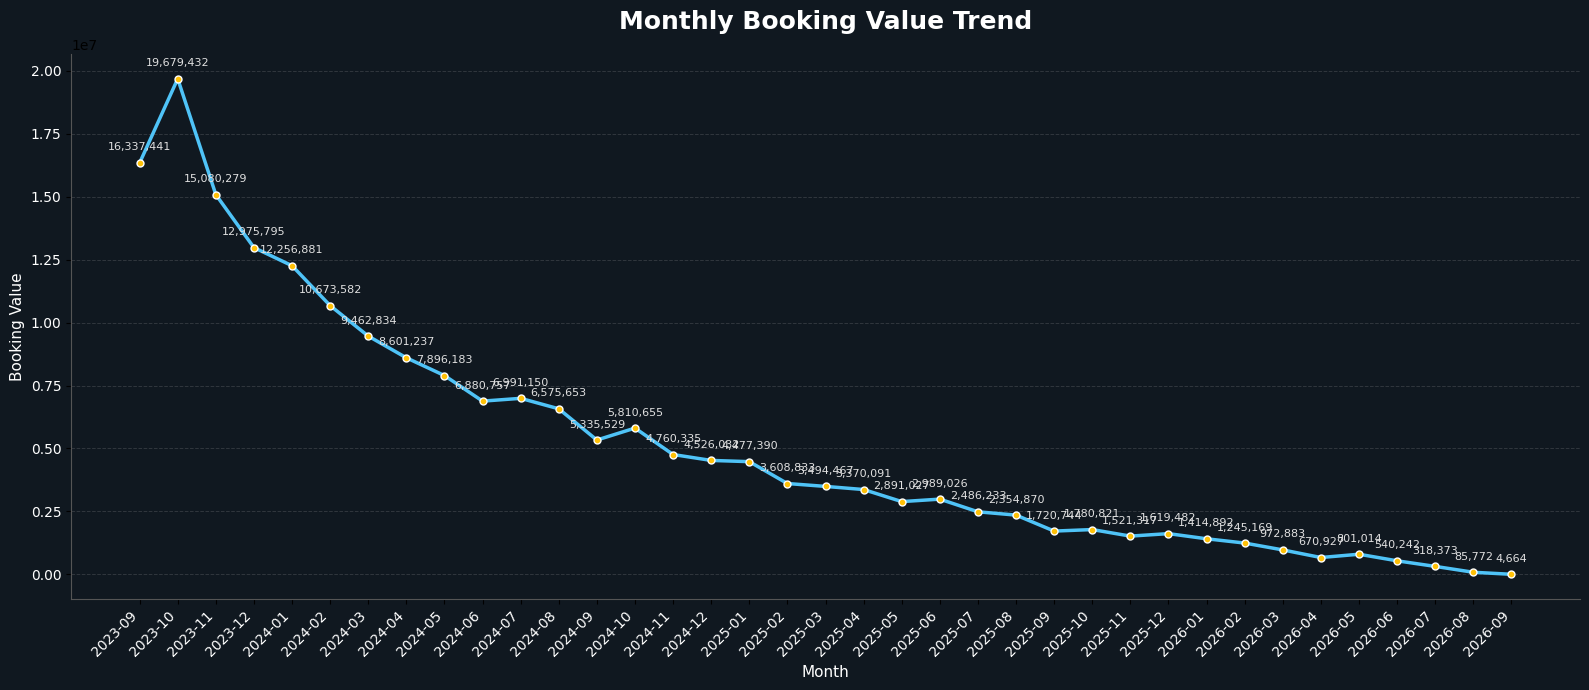

In [ ]:
# Monthly Booking Value Trend

monthly_booking_value = bookings.groupby(
    bookings['booking_date'].dt.to_period('M')
)['total_amount'].sum()

plt.figure(figsize=(16, 7))

plt.plot(
    monthly_booking_value.index.astype(str),
    monthly_booking_value.values,
    color='#4FC3F7',
    marker='o',
    markersize=5,
    linewidth=2.5,
    markerfacecolor='#FFC107',
    markeredgecolor='#FFFFFF',
    markeredgewidth=1
)

for x, y in zip(
    monthly_booking_value.index.astype(str),
    monthly_booking_value.values
):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        xytext=(0, 9),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='#E0E0E0'
    )

plt.title(
    'Monthly Booking Value Trend',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Month',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Booking Value',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=45,
    ha='right',
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

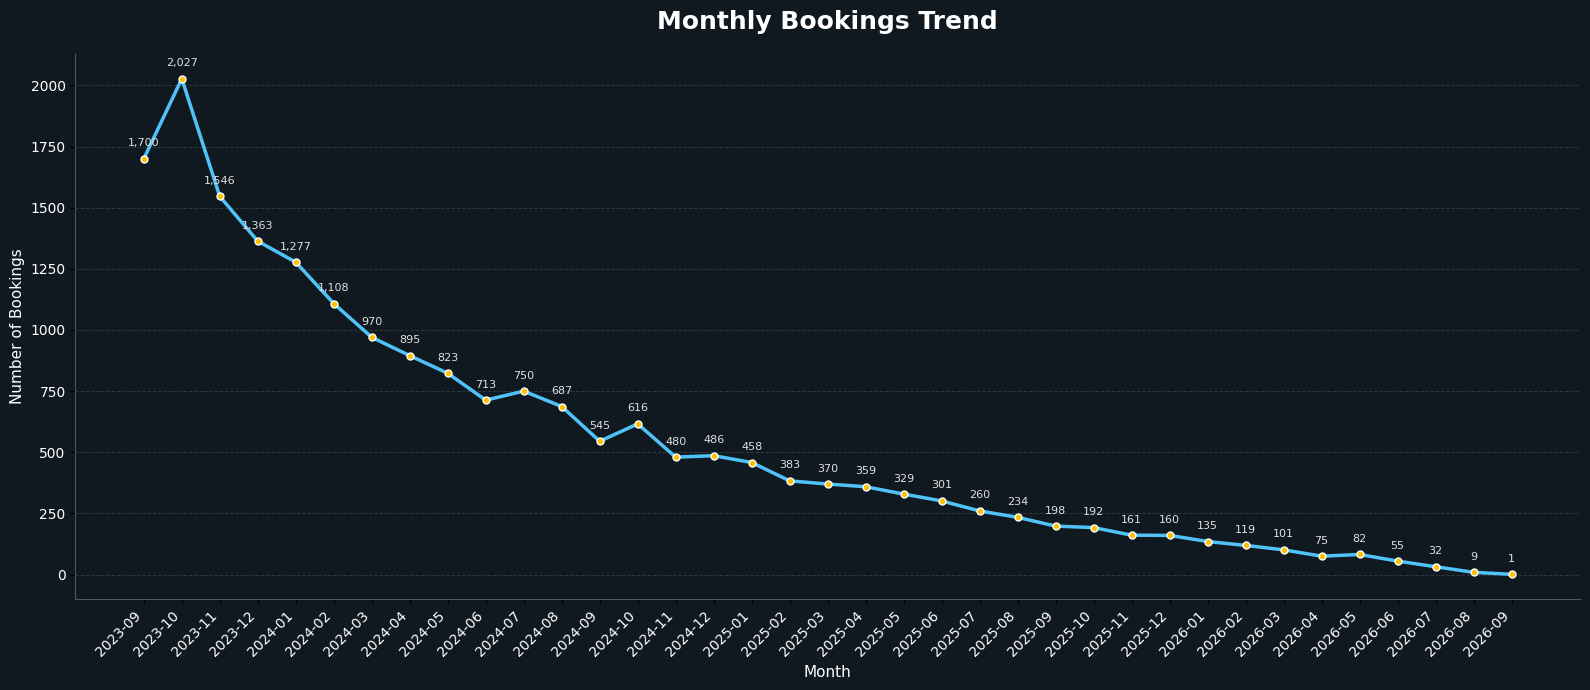

In [ ]:
# Monthly Bookings Trend

booking_by_month = bookings.groupby(
    bookings['booking_date'].dt.to_period('M')
)['booking_id'].count()

plt.figure(figsize=(16, 7))

plt.plot(
    booking_by_month.index.astype(str),
    booking_by_month.values,
    color='#4FC3F7',
    marker='o',
    markersize=5,
    linewidth=2.5,
    markerfacecolor='#FFC107',
    markeredgecolor='#FFFFFF',
    markeredgewidth=1
)

for x, y in zip(
    booking_by_month.index.astype(str),
    booking_by_month.values
):
    plt.annotate(
        f'{y:,}',
        (x, y),
        xytext=(0, 9),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='#E0E0E0'
    )

plt.title(
    'Monthly Bookings Trend',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Month',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Number of Bookings',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=45,
    ha='right',
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

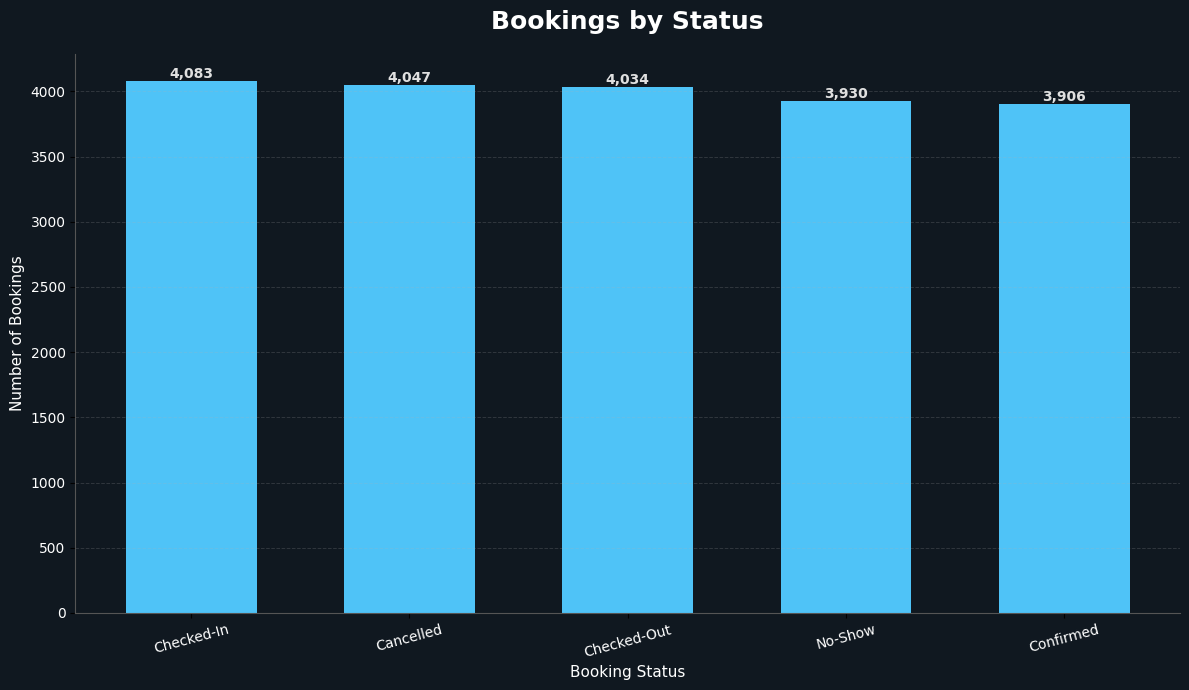

In [ ]:
# Bookings by Status

booking_by_status = bookings.groupby(
    'status'
)['booking_id'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    booking_by_status.index,
    booking_by_status.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Bookings by Status',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Booking Status',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Number of Bookings',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

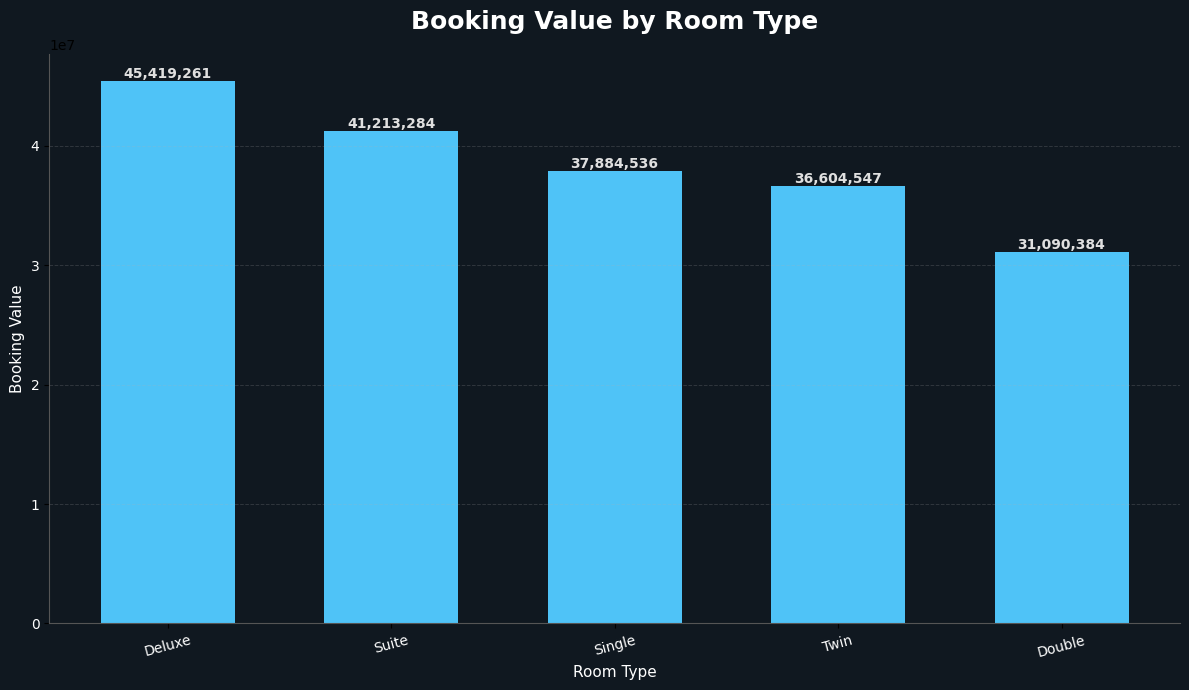

In [ ]:
# Booking Value by Room Type

booking_value_by_room_type = rooms.merge(
    bookings,
    on='room_id'
).groupby('room_type')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    booking_value_by_room_type.index,
    booking_value_by_room_type.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Booking Value by Room Type',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Room Type',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Booking Value',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

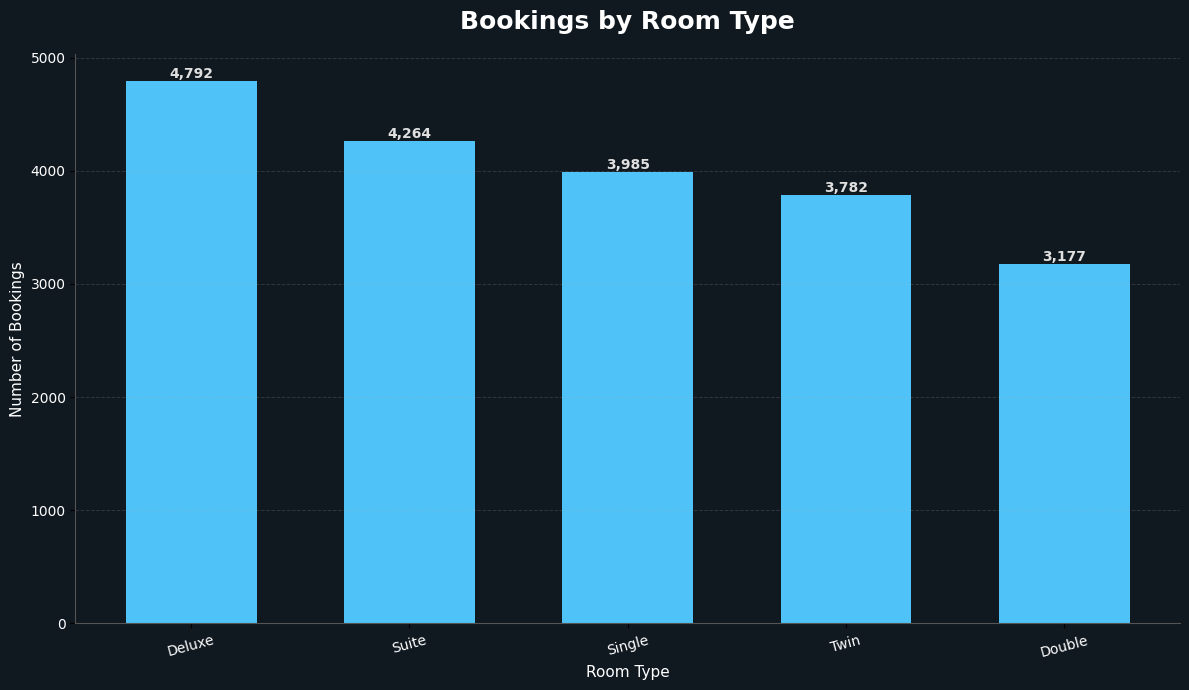

In [ ]:
# Bookings by Room Type

booking_by_room_type = rooms.merge(
    bookings,
    on='room_id'
).groupby('room_type')['booking_id'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    booking_by_room_type.index,
    booking_by_room_type.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Bookings by Room Type',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Room Type',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Number of Bookings',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

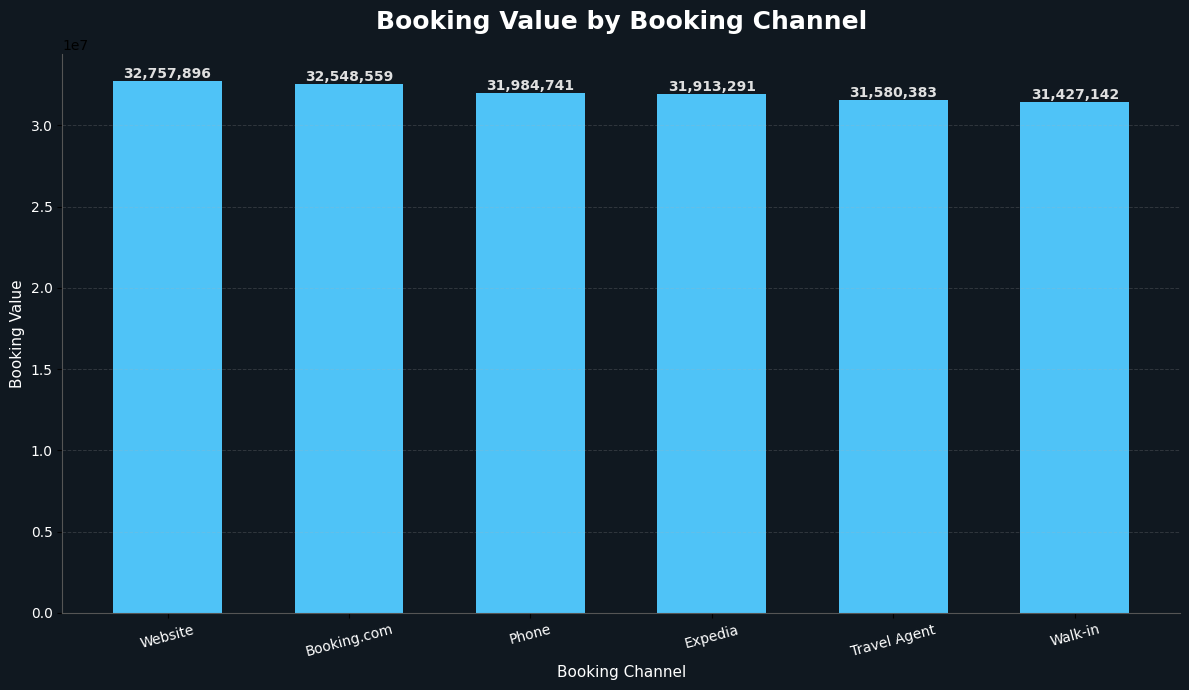

In [ ]:
# Booking Value by Booking Channel

booking_value_by_channel = bookings.groupby(
    'booking_channel'
)['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    booking_value_by_channel.index,
    booking_value_by_channel.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Booking Value by Booking Channel',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Booking Channel',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Booking Value',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

/tmp/ipykernel_571/302586724.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


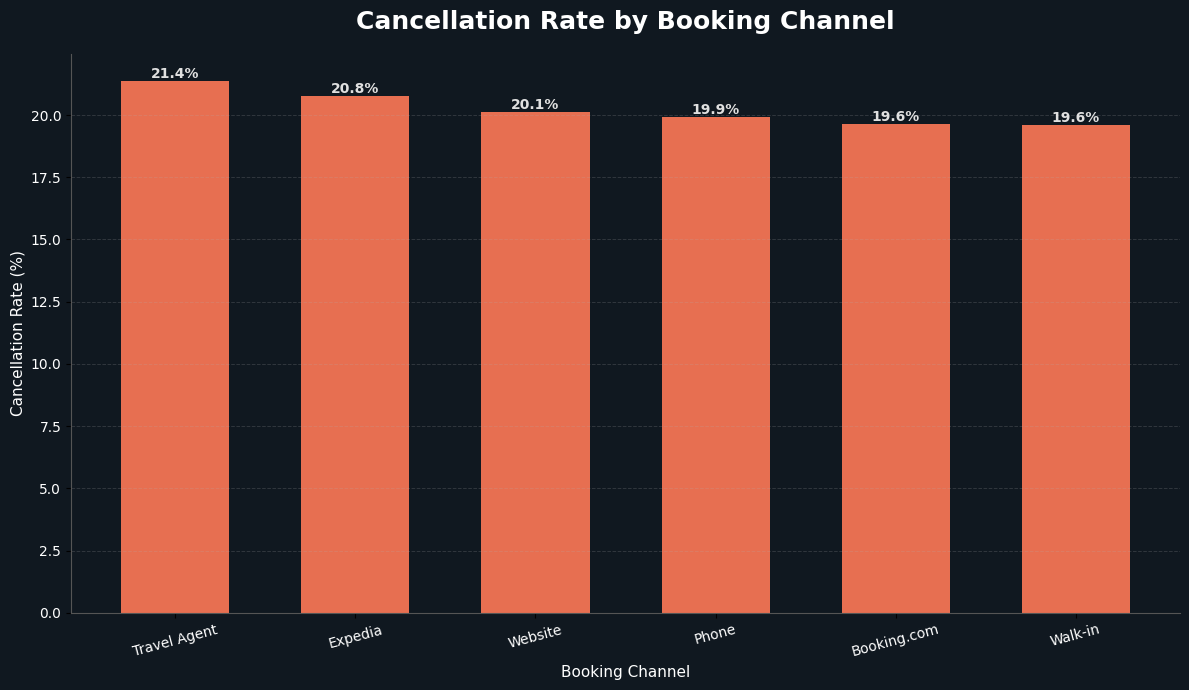

In [ ]:
# Cancellation Rate by Booking Channel

cancellation_by_channel = bookings.groupby(
    'booking_channel'
).apply(
    lambda x: (x['status'] == 'Cancelled').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    cancellation_by_channel.index,
    cancellation_by_channel.values,
    color='#E76F51',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Cancellation Rate by Booking Channel',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Booking Channel',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Cancellation Rate (%)',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

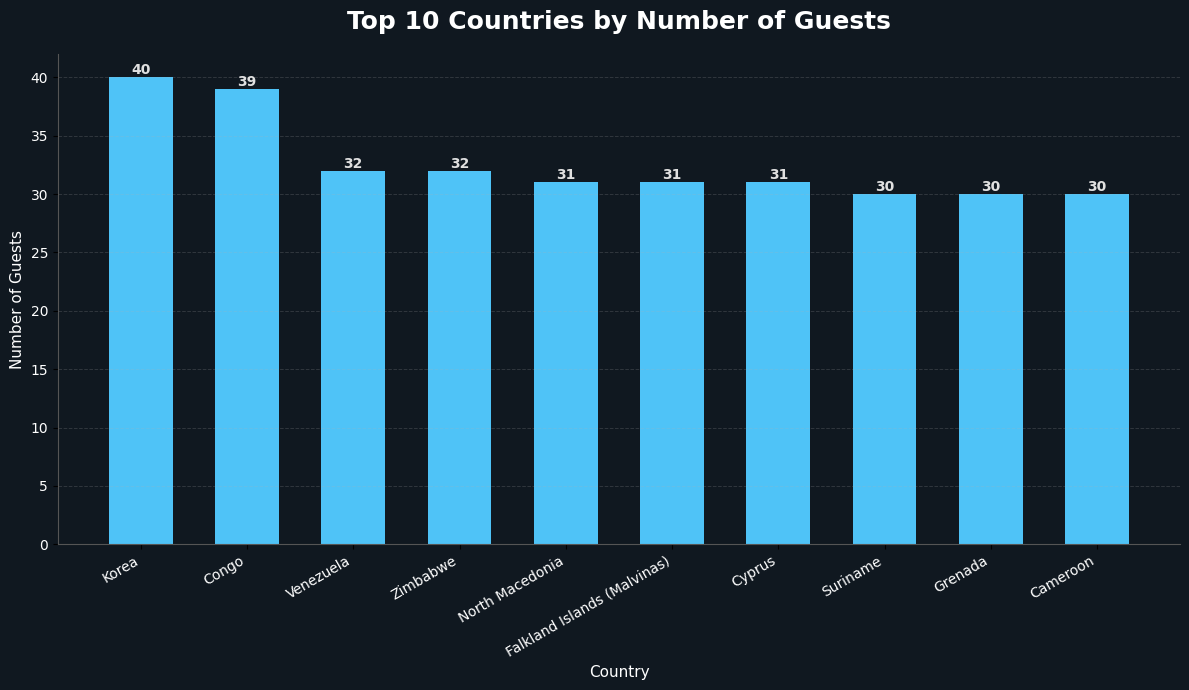

In [ ]:
# Top 10 Countries by Number of Guests

guests_by_country = gust.groupby(
    'country'
)['guest_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    guests_by_country.index,
    guests_by_country.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Top 10 Countries by Number of Guests',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Country',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Number of Guests',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=30,
    ha='right',
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

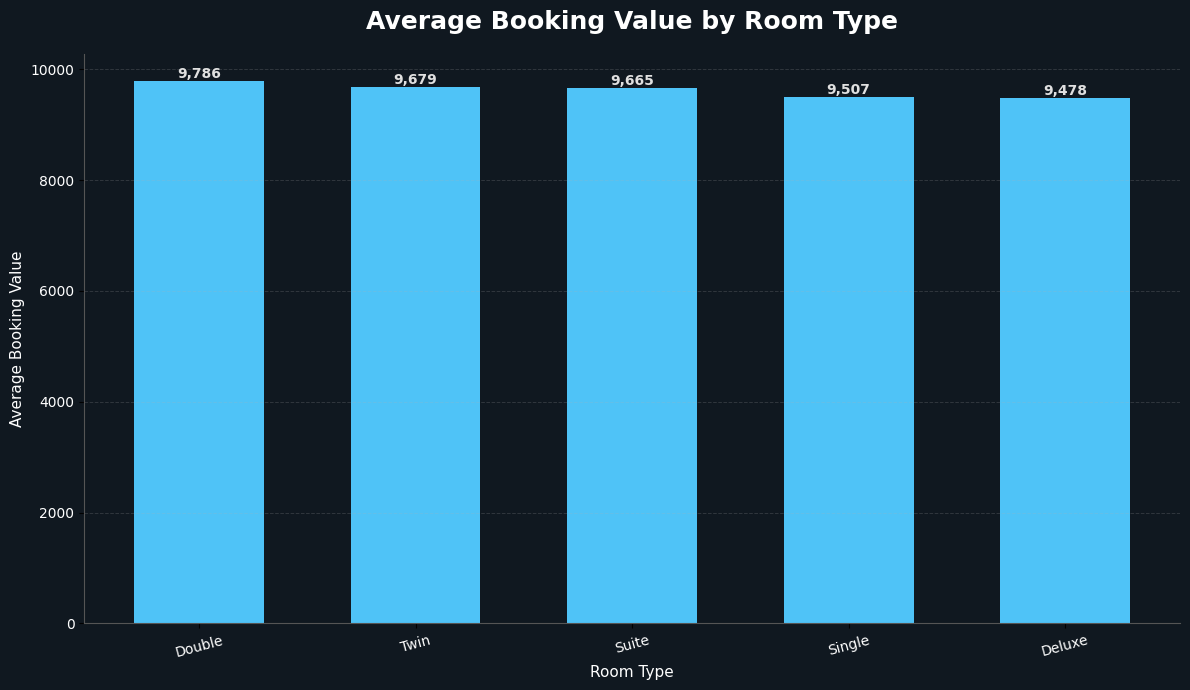

In [ ]:
# Average Booking Value by Room Type

avg_booking_value_by_room = rooms.merge(
    bookings,
    on='room_id'
).groupby('room_type')['total_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    avg_booking_value_by_room.index,
    avg_booking_value_by_room.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Average Booking Value by Room Type',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Room Type',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Average Booking Value',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

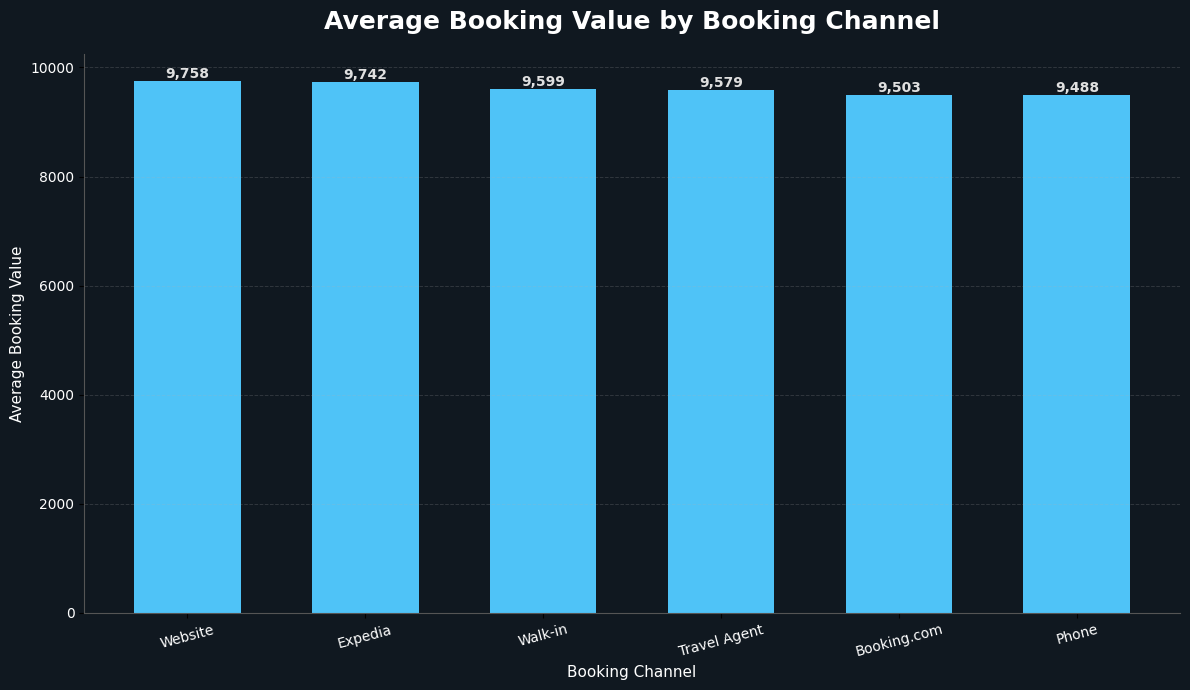

In [ ]:
# Average Booking Value by Booking Channel

avg_booking_value_by_channel = bookings.groupby(
    'booking_channel'
)['total_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    avg_booking_value_by_channel.index,
    avg_booking_value_by_channel.values,
    color='#4FC3F7',
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Average Booking Value by Booking Channel',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Booking Channel',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Average Booking Value',
    fontsize=11,
    color='white'
)

plt.xticks(
    rotation=15,
    color='white'
)

plt.yticks(color='white')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

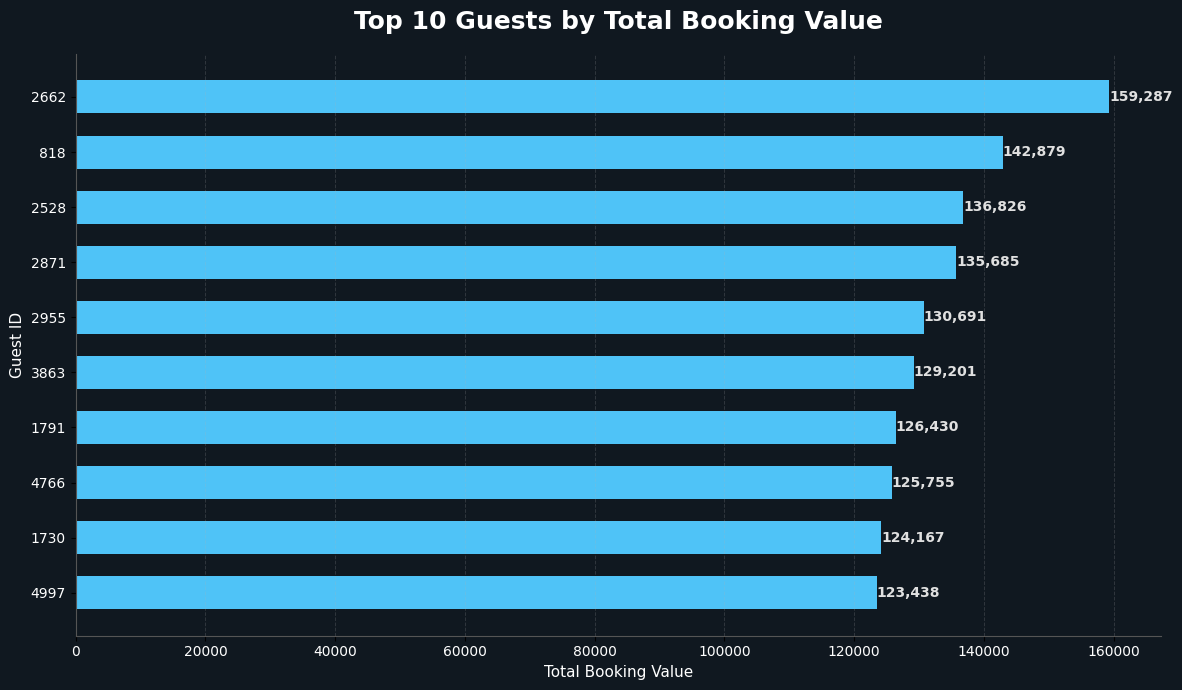

In [ ]:
# Top 10 Guests by Total Booking Value

top_10_guests = gust.merge(
    bookings,
    on='guest_id'
).groupby('guest_id')['total_amount'].sum().sort_values(
    ascending=False
).head(10).sort_values()

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_10_guests.index.astype(str),
    top_10_guests.values,
    color='#4FC3F7',
    height=0.6
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#E0E0E0'
    )

plt.title(
    'Top 10 Guests by Total Booking Value',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

plt.xlabel(
    'Total Booking Value',
    fontsize=11,
    color='white'
)

plt.ylabel(
    'Guest ID',
    fontsize=11,
    color='white'
)

plt.xticks(color='white')
plt.yticks(color='white')

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.7,
    alpha=0.2
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

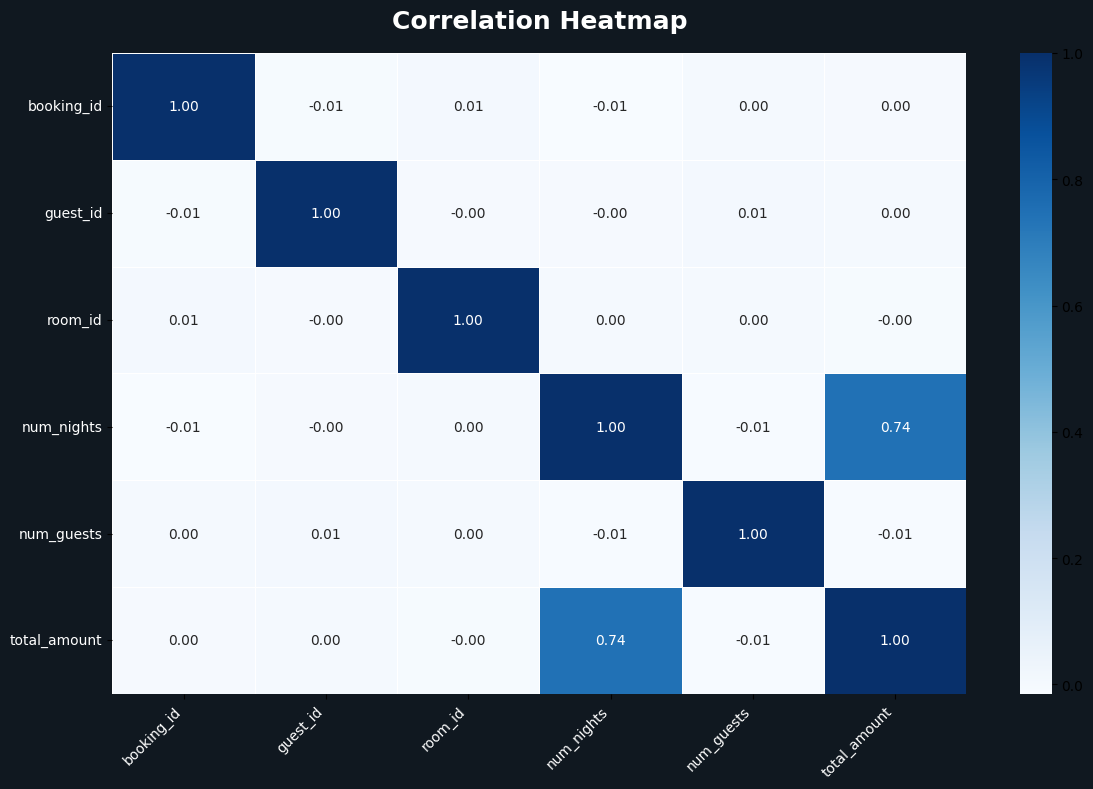

In [ ]:
# Correlation Heatmap

correlation = bookings.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=18
)

ax = plt.gca()

ax.set_facecolor('#101820')
plt.gcf().set_facecolor('#101820')

plt.xticks(
    color='white',
    rotation=45,
    ha='right'
)

plt.yticks(
    color='white',
    rotation=0
)

plt.tight_layout()
plt.show()